# 04 — Results & Discussion

What does the data actually tell us about the augmentation-to-automation transition?
This notebook synthesizes findings and produces the final rankings and visualizations.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_feature_matrix
from src.model import train_tipping_models, train_velocity_models, rank_tipping_candidates

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261'}

In [2]:
features = build_feature_matrix()
tip_results = train_tipping_models(features)
vel_results = train_velocity_models(features)

best_clf = max(tip_results, key=lambda r: r.metrics['auc_cv_mean'])
best_vel = max(vel_results, key=lambda r: r.metrics['r2_cv_mean'])
print(f"Best classifier: {best_clf.name} (AUC = {best_clf.metrics['auc_cv_mean']:.3f})")
print(f"Best regressor:  {best_vel.name} (R2 = {best_vel.metrics['r2_cv_mean']:.3f})")

Best classifier: RandomForest (AUC = 0.710)
Best regressor:  GradientBoosting (R2 = -0.018)


## Occupations that have genuinely tipped

With quality filtering, only 3 occupations crossed from augmentation-dominant
to automation-dominant during our observation window.

In [3]:
tipped = features[features['tipped'] == 1].sort_values('automation_delta', ascending=False)
print(f"{len(tipped)} occupations tipped from augmentation to automation:\n")
for _, row in tipped.iterrows():
    print(f"  {row['title']}")
    print(f"    {row['initial_automation_share']:.0%} -> {row['latest_automation_share']:.0%}  "
          f"({row['conversation_count']:.0f} conversations, {row['task_count']:.0f} tasks)")
    print()

3 occupations tipped from augmentation to automation:

  Survey Researchers
    34% -> 55%  (1667 conversations, 8 tasks)

  Computer Operators
    39% -> 53%  (2557 conversations, 6 tasks)

  Desktop Publishers
    40% -> 51%  (1615 conversations, 7 tasks)



## Tipping-point candidates

For occupations currently below 50% automation, which does the model rank
as most likely to be shifting toward automation?

**Caveat:** The model has modest predictive power (AUC ~0.71). This ranking
should be interpreted as "occupations with features associated with automation
shifts," not "occupations that will definitely automate."

In [4]:
ranking = rank_tipping_candidates(features, best_clf)

print(f"Top 20 tipping-point candidates (out of {len(ranking)} augmentation-dominant occupations):")
print()
display_cols = ['title', 'latest_automation_share', 'predicted_automation_probability',
                'conversation_count', 'task_count', 'mediansalary']
top20 = ranking[display_cols].head(20).copy()
top20.columns = ['Occupation', 'Current Auto%', 'P(shift)', 'Conversations', 'Tasks', 'Median Salary']
top20['Current Auto%'] = top20['Current Auto%'].map('{:.0%}'.format)
top20['P(shift)'] = top20['P(shift)'].map('{:.0%}'.format)
top20['Conversations'] = top20['Conversations'].map('{:,.0f}'.format)
top20['Median Salary'] = top20['Median Salary'].map('${:,.0f}'.format)
top20

Top 20 tipping-point candidates (out of 315 augmentation-dominant occupations):



,Occupation,Current Auto%,P(shift),Conversations,Tasks,Median Salary
0,"Internists, General",15%,64%,"1,015",7.0,"$194,500"
1,Legislators,41%,63%,280,5.0,"$24,670"
2,Biochemical Engineers,10%,62%,"5,154",7.0,"$96,980"
3,Logistics Managers,11%,61%,623,7.0,"$94,730"
4,Family and General Practitioners,15%,60%,569,8.0,"$201,100"
5,Waiters and Waitresses,36%,60%,320,4.0,"$21,780"
6,Midwives,13%,60%,"1,365",12.0,"$54,620"
7,Electrical Engineering Technicians,0%,60%,836,3.0,"$64,330"
8,Coaches and Scouts,12%,60%,800,11.0,"$33,780"
9,Rehabilitation Counselors,10%,60%,248,3.0,"$35,630"


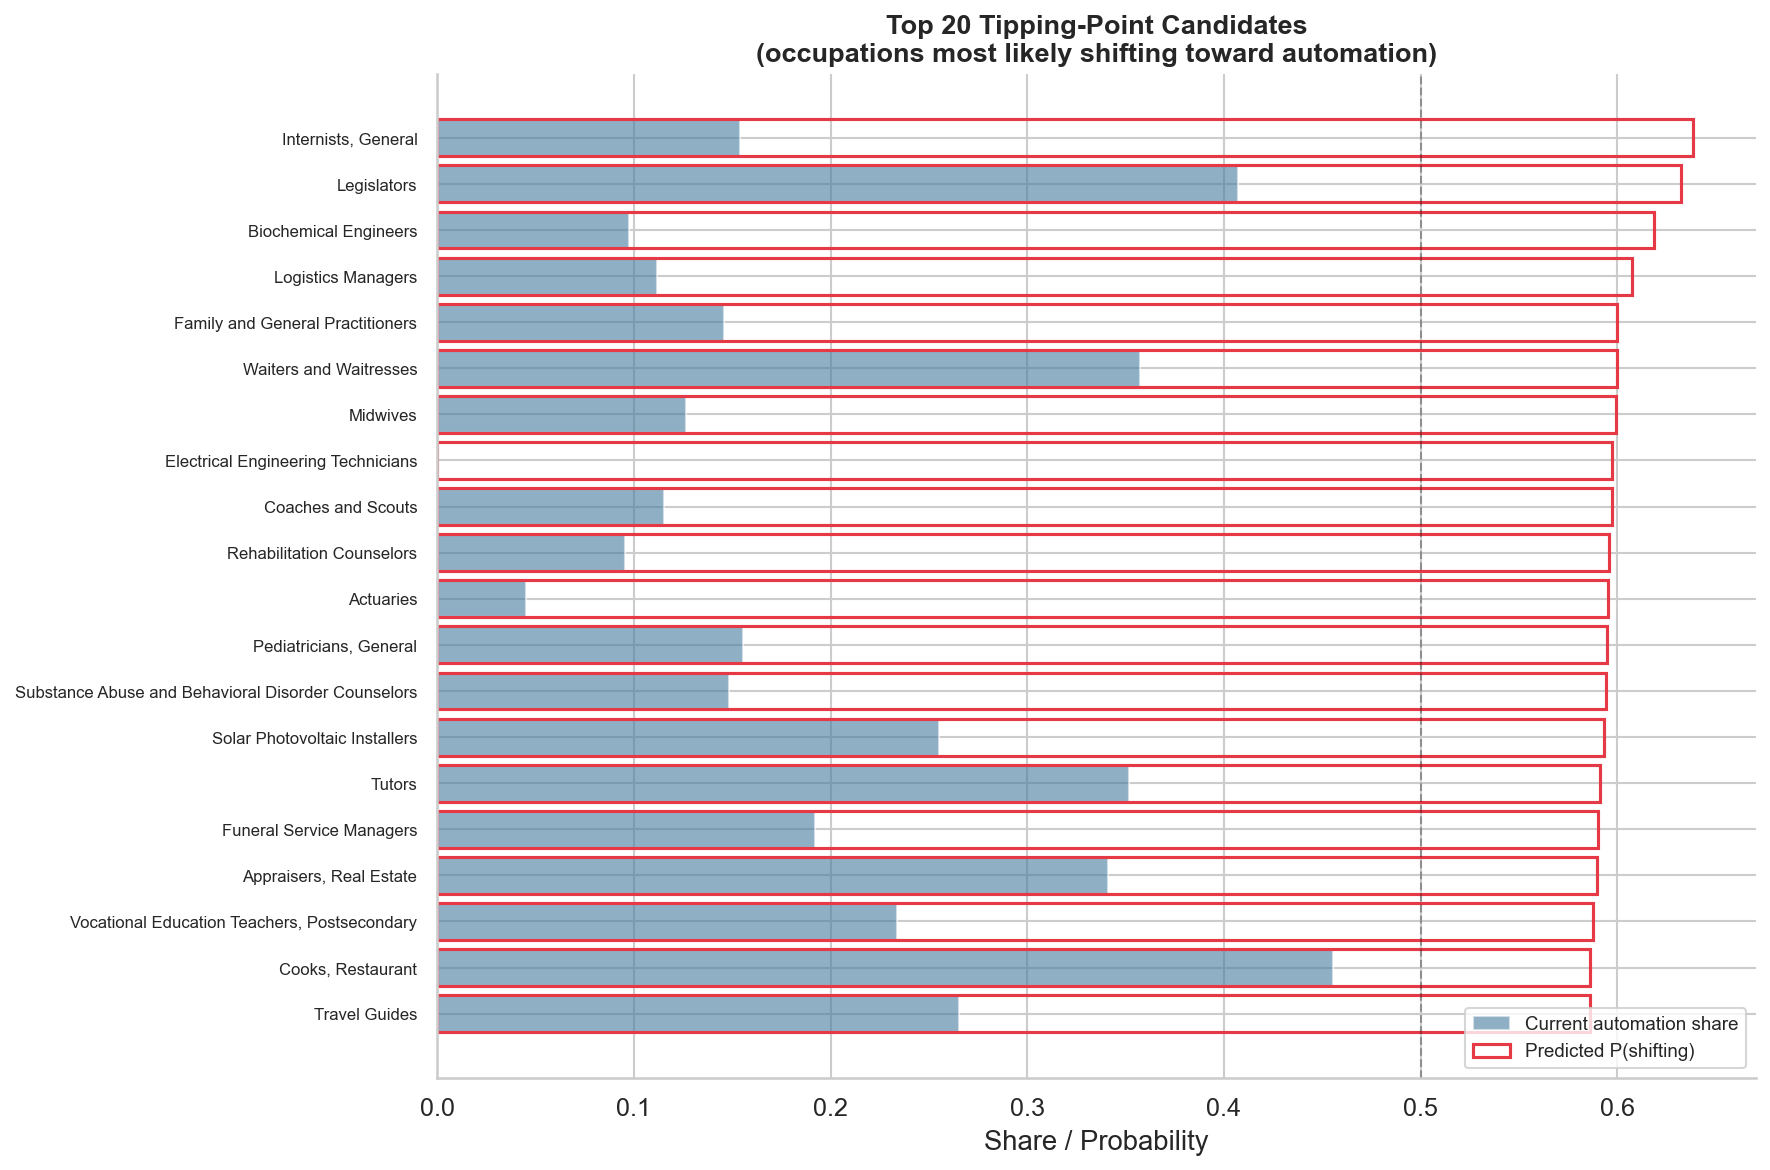

In [5]:
top_n = 20
top = ranking.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(top_n), top['latest_automation_share'],
        color=C['aug'], alpha=0.6, label='Current automation share')
ax.barh(range(top_n), top['predicted_automation_probability'],
        color='none', edgecolor=C['auto'], linewidth=1.5, label='Predicted P(shifting)')

ax.set_yticks(range(top_n))
ax.set_yticklabels(top['title'].values, fontsize=8)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.set_xlabel('Share / Probability')
ax.set_title('Top 20 Tipping-Point Candidates\n(occupations most likely shifting toward automation)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/12_tipping_candidates.png', bbox_inches='tight')
plt.show()

## What distinguishes occupations shifting toward automation?

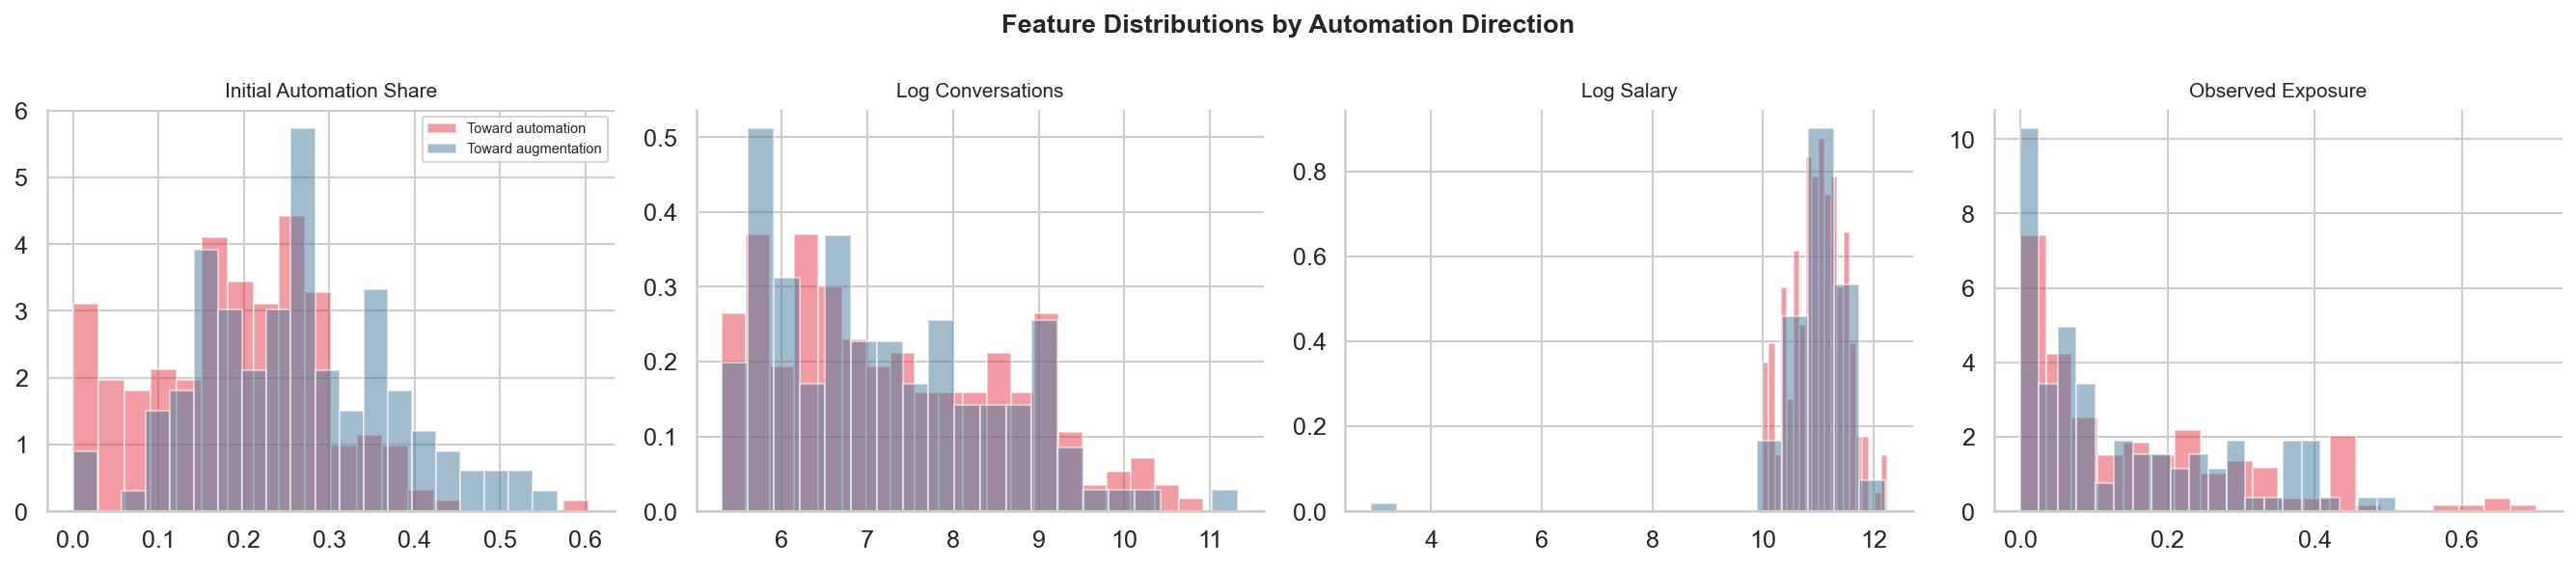

In [6]:
vel_df = features.dropna(subset=['automation_velocity']).copy()
vel_df['direction'] = np.where(vel_df['automation_delta'] > 0,
                                'Toward automation', 'Toward augmentation')

compare = ['initial_automation_share', 'log_conversations', 'log_salary', 'observed_exposure']
compare = [c for c in compare if c in vel_df.columns]

fig, axes = plt.subplots(1, len(compare), figsize=(4.5 * len(compare), 4))
for i, col in enumerate(compare):
    for dir_label, color in [('Toward automation', C['auto']), ('Toward augmentation', C['aug'])]:
        data = vel_df[vel_df['direction'] == dir_label][col].dropna()
        axes[i].hist(data, bins=20, alpha=0.5, color=color, label=dir_label, density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    if i == 0:
        axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Automation Direction', fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/13_distributions_by_direction.png', bbox_inches='tight')
plt.show()

## Occupation group frontier

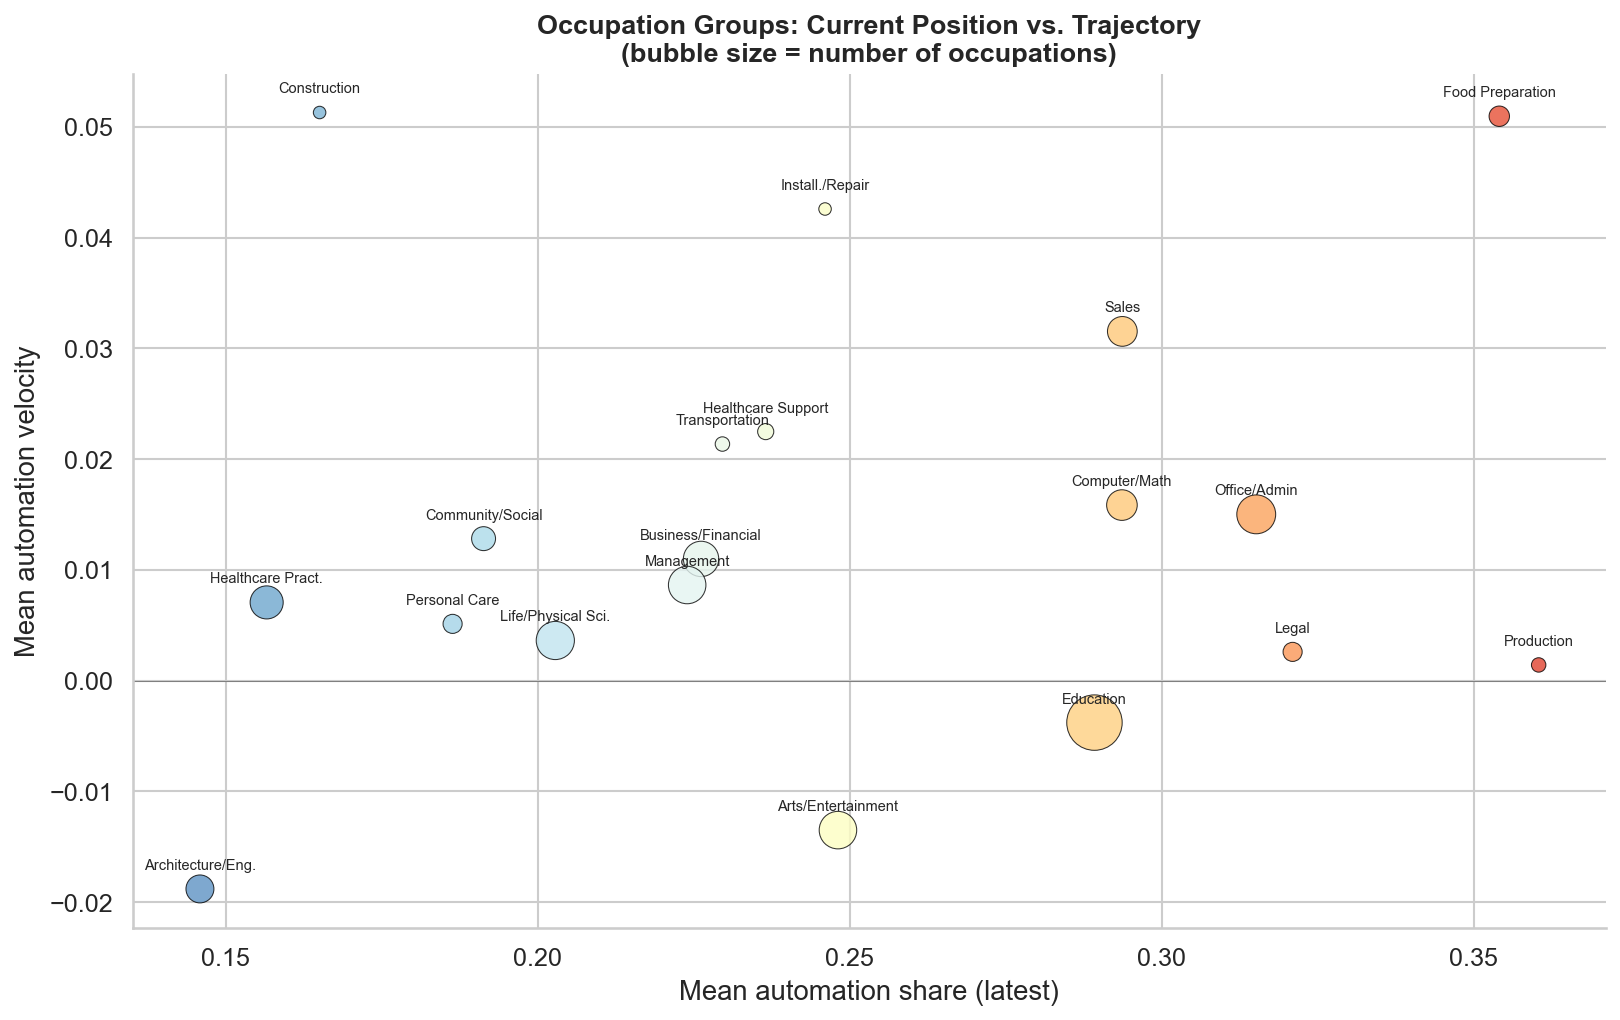

In [7]:
major_group_names = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Architecture/Eng.', '19': 'Life/Physical Sci.',
    '21': 'Community/Social', '23': 'Legal', '25': 'Education',
    '27': 'Arts/Entertainment', '29': 'Healthcare Pract.',
    '31': 'Healthcare Support', '33': 'Protective Service',
    '35': 'Food Preparation', '37': 'Building/Grounds',
    '39': 'Personal Care', '41': 'Sales', '43': 'Office/Admin',
    '47': 'Construction', '49': 'Install./Repair',
    '51': 'Production', '53': 'Transportation',
}

features['group_name'] = features['major_group'].map(major_group_names)
gs = (
    features.groupby('group_name')
    .agg(auto=('latest_automation_share', 'mean'), vel=('automation_velocity', 'mean'),
         n=('soc_code', 'count'))
    .dropna().query('n >= 3')
)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(gs['auto'], gs['vel'], s=gs['n'] * 12,
                     c=gs['auto'], cmap='RdYlBu_r', alpha=0.8,
                     edgecolors='black', linewidth=0.5, vmin=0.1, vmax=0.4)

for name, row in gs.iterrows():
    ax.annotate(name, (row['auto'], row['vel']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Mean automation share (latest)')
ax.set_ylabel('Mean automation velocity')
ax.set_title('Occupation Groups: Current Position vs. Trajectory\n(bubble size = number of occupations)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/14_group_frontier.png', bbox_inches='tight')
plt.show()

## Summary

In [8]:
print('The Jagged Adoption Frontier — Summary')
print('=' * 55)
print(f'Occupations analyzed (quality-filtered): {len(features)}')
print(f'Time periods:                           4 (Mar 2025 - Mar 2026)')
print(f'Automation-dominant (>50%):              {(features["latest_automation_share"] >= 0.5).sum()}')
print(f'Tipped during observation:              {features["tipped"].sum()}')
print(f'Shifting toward automation:             {(features["automation_delta"] > 0).sum()} ({(features["automation_delta"] > 0).mean():.0%})')
print()
print(f'Best velocity model:  {best_vel.name} (R2 = {best_vel.metrics["r2_cv_mean"]:.3f}) — weak')
print(f'Best direction model: {best_clf.name} (AUC = {best_clf.metrics["auc_cv_mean"]:.3f}) — modest')
print()
print('Key findings:')
print('1. Mean reversion dominates — high-automation occupations decelerate')
print('2. The frontier is jagged — wage explains almost nothing')
print('3. API usage is ~2x more automative than Claude.ai (channel > occupation)')
print('4. Individual trajectories are hard to predict (R2 ~ 0)')
print('5. Only 3 occupations genuinely tipped with reliable data')

The Jagged Adoption Frontier — Summary
Occupations analyzed (quality-filtered): 319
Time periods:                           4 (Mar 2025 - Mar 2026)
Automation-dominant (>50%):              4
Tipped during observation:              3
Shifting toward automation:             202 (63%)

Best velocity model:  GradientBoosting (R2 = -0.018) — weak
Best direction model: RandomForest (AUC = 0.710) — modest

Key findings:
1. Mean reversion dominates — high-automation occupations decelerate
2. The frontier is jagged — wage explains almost nothing
3. API usage is ~2x more automative than Claude.ai (channel > occupation)
4. Individual trajectories are hard to predict (R2 ~ 0)
5. Only 3 occupations genuinely tipped with reliable data


---

### What the data says vs. what it doesn't

**It says:**
- Most AI use remains augmentative — human-AI collaboration, not replacement
- There's strong convergence toward the mean in automation shares
- The API channel is where automation happens; Claude.ai is for collaboration
- The frontier between automation and augmentation is genuinely jagged

**It doesn't say:**
- Which specific occupations *will* automate (trajectories are noisy)
- Whether automation on Claude generalizes to other AI systems
- Whether the 12-month trend will continue or reverse
- What the causal mechanisms are behind the augmentation-to-automation transition